<a href="https://colab.research.google.com/github/ABBAS-37405/PYTHON-AND-DATA-SCIENCE/blob/main/PROJECT_BANK_CHURN_DATA_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load Data
This cell loads the `Bank+Churn+Data.xlsx` file into a pandas DataFrame and displays the first few rows to preview the data.

In [3]:
import pandas as pd

file_path = '/content/Bank+Churn+Data.xlsx'
df = pd.read_excel(file_path)

print(f"Successfully loaded '{file_path}' with {df.shape[0]} rows and {df.shape[1]} columns.")
display(df.head())

Successfully loaded '/content/Bank+Churn+Data.xlsx' with 500 rows and 13 columns.


,CustomerID,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn
0,1,Davis,764,Germany,Male,20,7,119274.87,3,1,0,107886.77,0
1,2,Smith,365,Spain,Female,64,3,203737.4,3,1,1,52848.11,0
2,3,Jones,519,Germany,Male,69,6,146780.5,3,0,0,94395.02,0
3,4,Jones,516,Germany,Female,59,0,23572.03,1,1,0,146739.55,0
4,5,Wilson,659,Spain,Female,21,2,7463.43,1,1,1,16036.55,0


### Initial Data Information
This cell displays the `df.info()` output, providing a summary of the DataFrame's structure, including column data types and non-null counts.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       500 non-null    int64  
 1   Surname          500 non-null    object 
 2   CreditScore      500 non-null    int64  
 3   Geography        500 non-null    object 
 4   Gender           500 non-null    object 
 5   Age              500 non-null    int64  
 6   Tenure           500 non-null    int64  
 7   Balance          500 non-null    object 
 8   NumOfProducts    500 non-null    int64  
 9   HasCrCard        500 non-null    int64  
 10  IsActiveMember   500 non-null    int64  
 11  EstimatedSalary  497 non-null    float64
 12  Churn            500 non-null    int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 50.9+ KB


### Clean 'Balance' Column
This cell cleans the 'Balance' column by removing non-numeric characters and converting it to a float data type. It then displays the updated data type and the first five rows of the cleaned column.

In [5]:
# Clean 'Balance' column: remove non-numeric characters and convert to float
df['Balance'] = df['Balance'].astype(str).str.replace(r'[^0-9.]', '', regex=True)
df['Balance'] = pd.to_numeric(df['Balance'], errors='coerce')

print("Data type of 'Balance' column after cleaning:")
display(df['Balance'].info())
print("First 5 rows of cleaned 'Balance' column:")
display(df['Balance'].head())

Data type of 'Balance' column after cleaning:
<class 'pandas.core.series.Series'>
RangeIndex: 500 entries, 0 to 499
Series name: Balance
Non-Null Count  Dtype  
--------------  -----  
499 non-null    float64
dtypes: float64(1)
memory usage: 4.0 KB


None

First 5 rows of cleaned 'Balance' column:


,Balance
0,119274.87
1,203737.40
2,146780.50
3,23572.03
4,7463.43


### Check for Missing Values
This cell identifies and displays the count of missing values for each column in the DataFrame.

In [6]:
missing_values = df.isnull().sum()
print("Missing values per column:")
display(missing_values[missing_values > 0])

Missing values per column:


,0
Balance,1
EstimatedSalary,3


### Impute Missing 'EstimatedSalary' Values
This cell imputes the missing values in the 'EstimatedSalary' column with the mean of the column, ensuring no missing values remain.

In [7]:
mean_estimated_salary = df['EstimatedSalary'].mean()
df['EstimatedSalary'] = df['EstimatedSalary'].fillna(mean_estimated_salary)

print(f"Missing values in 'EstimatedSalary' after imputation: {df['EstimatedSalary'].isnull().sum()}")

Missing values in 'EstimatedSalary' after imputation: 0


### Check 'Balance' Missing Values (Post-Cleaning)
This cell re-checks and displays the count of missing values specifically in the 'Balance' column after the cleaning operation.

In [8]:
print(f"Missing values in 'Balance' column: {df['Balance'].isnull().sum()}")

Missing values in 'Balance' column: 1


### Drop Rows with Missing 'Balance'
This cell drops any rows where the 'Balance' column still contains missing values, ensuring data integrity for this crucial column.

In [9]:
df.dropna(subset=['Balance'], inplace=True)

print(f"Missing values in 'Balance' column after dropping: {df['Balance'].isnull().sum()}")

Missing values in 'Balance' column after dropping: 0


### Check for Duplicate Rows
This cell counts and displays the number of duplicate rows in the DataFrame. If duplicates exist, it shows the first 5 duplicate rows.

In [10]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows in the DataFrame: {num_duplicates}")

if num_duplicates > 0:
    print("Displaying the first 5 duplicate rows:")
    display(df[df.duplicated()].head())

Number of duplicate rows in the DataFrame: 0


### Updated DataFrame Information
This cell displays the `df.info()` output again, showing the DataFrame's current structure after data cleaning and imputation steps.

In [11]:
print('Current DataFrame Information:')
df.info()

Current DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
Index: 499 entries, 0 to 499
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       499 non-null    int64  
 1   Surname          499 non-null    object 
 2   CreditScore      499 non-null    int64  
 3   Geography        499 non-null    object 
 4   Gender           499 non-null    object 
 5   Age              499 non-null    int64  
 6   Tenure           499 non-null    int64  
 7   Balance          499 non-null    float64
 8   NumOfProducts    499 non-null    int64  
 9   HasCrCard        499 non-null    int64  
 10  IsActiveMember   499 non-null    int64  
 11  EstimatedSalary  499 non-null    float64
 12  Churn            499 non-null    int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 54.6+ KB


### Average Credit Score by Geography
This cell calculates and displays the average credit score for customers grouped by their geographic location.

In [12]:
average_credit_score_by_geography = df.groupby('Geography')['CreditScore'].mean()
print("Average Credit Score by Geography:")
display(average_credit_score_by_geography)

Average Credit Score by Geography:


,CreditScore
Geography,
France,592.549708
Germany,579.694268
Spain,601.871345


### Average Account Balance by Gender and Geography
This cell calculates and displays the average account balance for customers, grouped by both their geographic location and gender.

In [13]:
average_balance_by_gender_and_geography = df.groupby(['Geography', 'Gender'])['Balance'].mean()
print("Average Account Balance by Gender and Geography:")
display(average_balance_by_gender_and_geography)

Average Account Balance by Gender and Geography:


Geography  Gender
France     Female    129576.988542
           Male      133204.760133
Germany    Female    140888.278310
           Male      128591.024651
Spain      Female    120986.237473
           Male      119558.159125
Name: Balance, dtype: float64

### Distribution of Active Members vs. Credit Card Ownership
This cell generates a cross-tabulation to show the relationship between customers having a credit card and their status as an active member.

In [14]:
cross_tab = pd.crosstab(df['HasCrCard'], df['IsActiveMember'])
print("Distribution of active members vs. non-active members according to having a credit card:")
display(cross_tab)

Distribution of active members vs. non-active members according to having a credit card:


IsActiveMember,0,1
HasCrCard,,
0,139,113
1,123,124


### Customer Churn Rate per Number of Products Used
This cell calculates and displays the churn rate for customers based on the number of products they use.

In [15]:
churn_by_products = df.groupby('NumOfProducts')['Churn'].value_counts().unstack(fill_value=0)
churn_by_products.columns = ['NoChurn', 'Churn']

churn_by_products['ChurnRate'] = (churn_by_products['Churn'] / (churn_by_products['NoChurn'] + churn_by_products['Churn'])) * 100

print("Customer Churn Rate per Number of Products Used:")
display(churn_by_products)

Customer Churn Rate per Number of Products Used:


,NoChurn,Churn,ChurnRate
NumOfProducts,,,
1,56,69,55.200000
2,60,74,55.223881
3,53,65,55.084746
4,58,64,52.459016


### Average Credit Score by Tenure and Churn Status
This cell calculates and displays the average credit score, grouped by customer tenure and their churn status (churned vs. non-churned).

In [16]:
average_credit_score_tenure_churn = df.groupby(['Tenure', 'Churn'])['CreditScore'].mean().unstack()
print("Average Credit Score by Tenure and Churn Status:")
display(average_credit_score_tenure_churn)

Average Credit Score by Tenure and Churn Status:


Churn,0,1
Tenure,,
0,615.307692,589.176471
1,591.000000,616.833333
2,618.590909,568.880000
3,541.625000,637.666667
4,606.086957,617.666667
5,625.200000,605.250000
6,540.263158,572.535714
7,595.764706,567.269231
8,590.800000,598.958333


### Average Estimated Salary for Churned Customers
This cell calculates and displays the average estimated salary specifically for customers who have churned.

In [17]:
average_salary_churned = df[df['Churn'] == 1]['EstimatedSalary'].mean()
print(f"Average Estimated Salary for Churned Customers: {average_salary_churned:.2f}")

Average Estimated Salary for Churned Customers: 83428.09


### Chi-squared Test: Number of Products vs. Churn
This cell performs a chi-squared test for independence between the 'NumOfProducts' and 'Churn' columns to determine if there's a statistically significant association.

In [18]:
from scipy.stats import chi2_contingency

# Create a contingency table between 'NumOfProducts' and 'Churn'
contingency_table = pd.crosstab(df['NumOfProducts'], df['Churn'])

# Perform the chi-squared test for independence
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-squared test results for NumOfProducts vs. Churn:")
print(f"Chi-squared statistic: {chi2:.2f}")
print(f"P-value: {p_value:.3f}")

alph = 0.05
if p_value < alph:
    print(f"Since the p-value ({p_value:.3f}) is less than the significance level ({alph}), we reject the null hypothesis.")
    print("There is a statistically significant association between the number of products used and customer churn.")
else:
    print(f"Since the p-value ({p_value:.3f}) is greater than the significance level ({alph}), we fail to reject the null hypothesis.")
    print("There is no statistically significant association between the number of products used and customer churn.")

Chi-squared test results for NumOfProducts vs. Churn:
Chi-squared statistic: 0.27
P-value: 0.965
Since the p-value (0.965) is greater than the significance level (0.05), we fail to reject the null hypothesis.
There is no statistically significant association between the number of products used and customer churn.


### Statistical Comparison of Credit Score by Tenure and Churn Status (T-test)
This cell performs independent t-tests for each tenure group to compare the average credit scores of churned and non-churned customers, and displays the results including p-values and significance.

In [19]:
import pandas as pd
from scipy.stats import ttest_ind

# Display the previously calculated average credit score by tenure and churn status
print("Average Credit Score by Tenure and Churn Status:")
display(average_credit_score_tenure_churn)

# Perform independent t-tests for each tenure group
tenure_groups = df['Tenure'].unique()
tenure_groups.sort()

test_results = []

for tenure in tenure_groups:
    # Filter data for the current tenure group
    df_tenure = df[df['Tenure'] == tenure]

    # Separate credit scores for churned and non-churned customers
    credit_score_churned = df_tenure[df_tenure['Churn'] == 1]['CreditScore']
    credit_score_no_churn = df_tenure[df_tenure['Churn'] == 0]['CreditScore']

    # Ensure both groups have data to perform the t-test
    if len(credit_score_churned) > 1 and len(credit_score_no_churn) > 1:
        # Perform independent t-test
        t_stat, p_value = ttest_ind(credit_score_churned, credit_score_no_churn, equal_var=False) # Welch's t-test

        # Determine significance
        alpha = 0.05
        significant = 'Yes' if p_value < alpha else 'No'

        test_results.append({
            'Tenure': tenure,
            'Churn_Mean_CreditScore': credit_score_churned.mean(),
            'NoChurn_Mean_CreditScore': credit_score_no_churn.mean(),
            'T_Statistic': t_stat,
            'P_Value': p_value,
            'Significant_Difference_at_0.05': significant
        })
    else:
        test_results.append({
            'Tenure': tenure,
            'Churn_Mean_CreditScore': credit_score_churned.mean() if len(credit_score_churned) > 0 else None,
            'NoChurn_Mean_CreditScore': credit_score_no_churn.mean() if len(credit_score_no_churn) > 0 else None,
            'T_Statistic': 'Not enough data',
            'P_Value': 'Not enough data',
            'Significant_Difference_at_0.05': 'Not applicable'
        })

results_df = pd.DataFrame(test_results)
print("\nStatistical Comparison of Credit Score by Tenure and Churn Status (T-test results):")
display(results_df)


Average Credit Score by Tenure and Churn Status:


Churn,0,1
Tenure,,
0,615.307692,589.176471
1,591.000000,616.833333
2,618.590909,568.880000
3,541.625000,637.666667
4,606.086957,617.666667
5,625.200000,605.250000
6,540.263158,572.535714
7,595.764706,567.269231
8,590.800000,598.958333



Statistical Comparison of Credit Score by Tenure and Churn Status (T-test results):


,Tenure,Churn_Mean_CreditScore,NoChurn_Mean_CreditScore,T_Statistic,P_Value,Significant_Difference_at_0.05
0,0,589.176471,615.307692,-0.644297,0.523314,No
1,1,616.833333,591.000000,0.589050,0.559000,No
2,2,568.880000,618.590909,-1.286885,0.204770,No
3,3,637.666667,541.625000,2.068819,0.046556,Yes
4,4,617.666667,606.086957,0.308179,0.759472,No
5,5,605.250000,625.200000,-0.528584,0.600024,No
6,6,572.535714,540.263158,0.773073,0.444801,No
7,7,567.269231,595.764706,-0.689271,0.495168,No
8,8,598.958333,590.800000,0.157267,0.876210,No
9,9,556.606061,562.550000,-0.150004,0.881522,No


### Compare Average Estimated Salary: Churned vs. Non-Churned
This cell calculates and compares the average estimated salary for both churned and non-churned customers, providing an initial assessment of the difference.

In [20]:
average_salary_non_churned = df[df['Churn'] == 0]['EstimatedSalary'].mean()
print(f"Average Estimated Salary for Non-Churned Customers: {average_salary_non_churned:.2f}")

print(f"\nAverage Estimated Salary for Churned Customers: {average_salary_churned:.2f}")

if average_salary_churned > average_salary_non_churned:
    print("Churned customers have a higher average estimated salary than non-churned customers.")
elif average_salary_churned < average_salary_non_churned:
    print("Non-churned customers have a higher average estimated salary than churned customers.")
else:
    print("There is no significant difference in average estimated salary between churned and non-churned customers.")

Average Estimated Salary for Non-Churned Customers: 80771.20

Average Estimated Salary for Churned Customers: 83428.09
Churned customers have a higher average estimated salary than non-churned customers.


### Independent Samples T-test for Estimated Salary (Churned vs. Non-Churned)
This cell performs an independent samples t-test to statistically assess if there's a significant difference in the average estimated salary between churned and non-churned customers.

In [22]:
from scipy.stats import ttest_ind

# Separate EstimatedSalary for churned and non-churned customers
salary_churned = df[df['Churn'] == 1]['EstimatedSalary']
salary_non_churned = df[df['Churn'] == 0]['EstimatedSalary']

# Perform independent t-test (assuming equal variances with equal_var=True)
t_stat, p_value = ttest_ind(salary_churned, salary_non_churned, equal_var=True)

alpha = 0.05

print("Independent Samples T-test Results for Estimated Salary (Churned vs. Non-Churned) - Assuming Equal Variances:\n")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")

if p_value < alpha:
    print(f"Since the P-value ({p_value:.3f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("There is a statistically significant difference in average estimated salary between churned and non-churned customers.")
else:
    print(f"Since the P-value ({p_value:.3f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in average estimated salary between churned and non-churned customers.")

Independent Samples T-test Results for Estimated Salary (Churned vs. Non-Churned) - Assuming Equal Variances:

T-statistic: 0.722
P-value: 0.471
Since the P-value (0.471) is greater than the significance level (0.05), we fail to reject the null hypothesis.
There is no statistically significant difference in average estimated salary between churned and non-churned customers.


### One-Way ANOVA Test for Credit Score across Geography
This cell performs a one-way ANOVA test to determine if there are statistically significant differences in average credit scores among customers from different geographic locations (France, Germany, Spain).

In [24]:
from scipy.stats import f_oneway

# Extract credit scores for each geographic group
france_credit_score = df[df['Geography'] == 'France']['CreditScore']
germany_credit_score = df[df['Geography'] == 'Germany']['CreditScore']
spain_credit_score = df[df['Geography'] == 'Spain']['CreditScore']

# Perform one-way ANOVA test
f_statistic, p_value = f_oneway(france_credit_score, germany_credit_score, spain_credit_score)

alpha = 0.05 # Significance level

print("One-Way ANOVA Test for Credit Score across Geography:")
print(f"F-statistic: {f_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

if p_value < alpha:
    print(f"Since the P-value ({p_value:.3f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("There is a statistically significant difference in average credit scores among different geographic locations.")
else:
    print(f"Since the P-value ({p_value:.3f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in average credit scores among different geographic locations.")

One-Way ANOVA Test for Credit Score across Geography:
F-statistic: 1.066
P-value: 0.345
Since the P-value (0.345) is greater than the significance level (0.05), we fail to reject the null hypothesis.
There is no statistically significant difference in average credit scores among different geographic locations.


### Visualize Credit Score Distribution by Geography
This cell generates a box plot to visually compare the distribution of credit scores across the different geographic locations. This visualization helps in understanding the spread and central tendency of credit scores for each region.

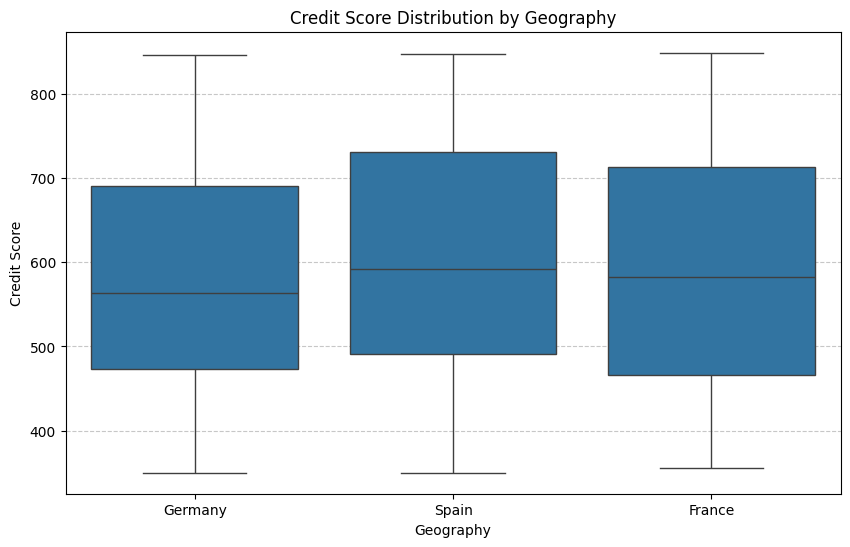

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='Geography', y='CreditScore', data=df)
plt.title('Credit Score Distribution by Geography')
plt.xlabel('Geography')
plt.ylabel('Credit Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()